# MNIST Handwritten Digit Classification with Deep Learning

**CSCI 394 - Spring 2026 Tutorial**

In this tutorial, you will learn how to build a fully connected (dense) neural network to classify handwritten digits from the MNIST dataset using PyTorch.

## What you will learn

1. How to load and explore the MNIST dataset
2. How to build a fully connected neural network in PyTorch
3. How to train the model using mini-batch gradient descent
4. How to evaluate model performance on test data
5. How to visualize training progress and predictions

## Background: The MNIST Dataset

MNIST (Modified National Institute of Standards and Technology) is one of the most well-known benchmark datasets in machine learning. It contains:

- **60,000 training images** and **10,000 test images**
- Each image is a **28x28 grayscale** picture of a handwritten digit (0-9)
- Pixel values range from 0 (black) to 255 (white)

Despite being considered a "solved" problem today (state-of-the-art accuracy > 99.7%), MNIST remains an excellent starting point for learning deep learning because:
- It's small enough to train quickly on any hardware
- The task is intuitive (recognizing digits)
- It demonstrates all the core concepts of supervised classification

## Step 0: Setup (Google Colab)

If you are running this notebook on Google Colab, PyTorch is already pre-installed. The cell below verifies your setup and enables GPU acceleration if available.

**To enable GPU on Colab:** Go to `Runtime > Change runtime type > Hardware accelerator > GPU`.

In [1]:
# Install dependencies (only needed if not on Colab)
!pip install torch torchvision matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time

print(f"PyTorch version: {torch.__version__}")

# Select device: use GPU if available, otherwise CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple MPS (Metal Performance Shaders)")
else:
    device = torch.device("cpu")
    print("Using CPU")

print(f"Device: {device}")

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
PyTorch version: 2.10.0
Using Apple MPS (Metal Performance Shaders)
Device: mps


## Step 1: Load and Explore the MNIST Dataset

PyTorch's `torchvision` library provides convenient access to many standard datasets. We use `transforms.ToTensor()` to convert images from PIL format to PyTorch tensors and normalize pixel values from [0, 255] to [0.0, 1.0].

### What is a DataLoader?

A `DataLoader` wraps a dataset and provides:
- **Batching**: groups samples into mini-batches for efficient processing
- **Shuffling**: randomizes the order of samples each epoch (important for training)
- **Parallel loading**: can use multiple workers to load data in the background

In [2]:
# Hyperparameters
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 1e-3
SEED = 42

torch.manual_seed(SEED)

# Download and load MNIST
transform = transforms.ToTensor()  # Converts [0,255] -> [0.0, 1.0]

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples:     {len(test_dataset)}")
print(f"Image shape:      {train_dataset[0][0].shape}  (channels x height x width)")
print(f"Number of classes: 10 (digits 0-9)")
print(f"Batches per epoch: {len(train_loader)}")

Training samples: 60000
Test samples:     10000
Image shape:      torch.Size([1, 28, 28])  (channels x height x width)
Number of classes: 10 (digits 0-9)
Batches per epoch: 469


### Visualize some training examples

Let's look at a few samples from the dataset to understand what we're working with.

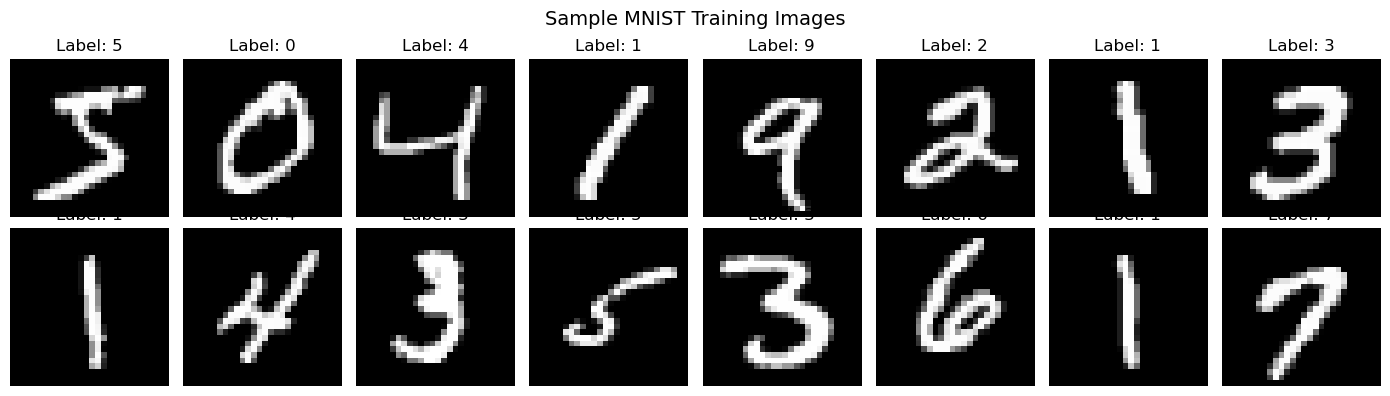

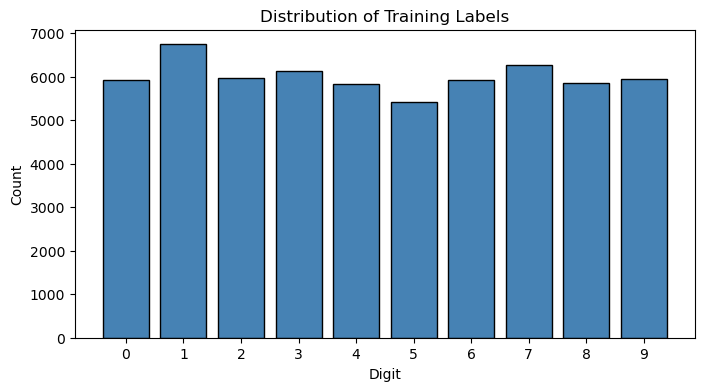

In [3]:
# Visualize some training examples
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.suptitle('Sample MNIST Training Images', fontsize=14)
plt.tight_layout()
plt.show()

# Show the distribution of labels
labels = [train_dataset[i][1] for i in range(len(train_dataset))]
plt.figure(figsize=(8, 4))
plt.hist(labels, bins=range(11), align='left', rwidth=0.8, color='steelblue', edgecolor='black')
plt.xticks(range(10))
plt.xlabel('Digit')
plt.ylabel('Count')
plt.title('Distribution of Training Labels')
plt.show()

## Step 2: Build the Neural Network

We will build a **fully connected (dense) neural network** with the following architecture:

```
Input (28x28 = 784 pixels)
  -> Flatten
  -> Linear(784, 256) + ReLU
  -> Linear(256, 128) + ReLU  
  -> Linear(128, 10)          (10 output classes)
```

### Key concepts:

- **Flatten**: Reshapes the 2D image (28x28) into a 1D vector (784) because fully connected layers expect 1D input
- **Linear layer**: `y = Wx + b`, a matrix multiplication followed by a bias addition. Each neuron is connected to every neuron in the previous layer
- **ReLU (Rectified Linear Unit)**: `f(x) = max(0, x)`, a simple non-linear activation function. Without non-linearities, stacking linear layers would still be a single linear transformation
- **Output layer**: 10 neurons (one per digit class), producing raw scores (logits)

In [4]:
class MNISTNet(nn.Module):
    """Fully connected neural network for MNIST classification."""
    
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),              # 28x28 -> 784
            nn.Linear(28 * 28, 256),   # 784 -> 256
            nn.ReLU(),
            nn.Linear(256, 128),       # 256 -> 128
            nn.ReLU(),
            nn.Linear(128, 10),        # 128 -> 10 (digit classes)
        )
    
    def forward(self, x):
        return self.net(x)

# Create the model and move it to the device (GPU/CPU)
model = MNISTNet().to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model architecture:\n{model}")
print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Model architecture:
MNISTNet(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total parameters:     235,146
Trainable parameters: 235,146


## Step 3: Define Loss Function and Optimizer

### Cross-Entropy Loss

For multi-class classification, we use **Cross-Entropy Loss** (also called log loss). It combines:
1. **Softmax**: converts raw logits to probabilities (values between 0 and 1 that sum to 1)
2. **Negative log-likelihood**: penalizes the model based on how confident it was in the *correct* class

$$\text{Loss} = -\log\left(\frac{e^{z_y}}{\sum_{j} e^{z_j}}\right)$$

where $z_y$ is the logit for the correct class $y$.

### Adam Optimizer

**Adam** (Adaptive Moment Estimation) is a popular optimizer that adapts the learning rate for each parameter individually using estimates of first and second moments of the gradients. It generally converges faster than plain SGD.

In [6]:
# Loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Loss function: {loss_fn}")
print(f"Optimizer: Adam with lr={LEARNING_RATE}")

Loss function: CrossEntropyLoss()
Optimizer: Adam with lr=0.001


## Step 4: Training Loop

The training process follows this pattern for each epoch:

1. **Forward pass**: Feed input through the network to get predictions
2. **Compute loss**: Compare predictions to true labels
3. **Backward pass**: Compute gradients of the loss with respect to all parameters (backpropagation)
4. **Update weights**: Adjust parameters in the direction that reduces the loss (gradient descent)

After each epoch, we evaluate on the test set to monitor generalization performance.

### Important PyTorch details:
- `model.train()`: Enables training-specific behaviors (e.g., dropout)
- `model.eval()`: Disables training-specific behaviors for evaluation  
- `optimizer.zero_grad()`: Clears gradients from the previous step (PyTorch accumulates gradients by default)
- `torch.no_grad()`: Disables gradient computation during evaluation (saves memory and computation)

In [8]:
def evaluate(model, loader, loss_fn, device):
    """Evaluate the model on a dataset."""
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_seen = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            
            logits = model(images)
            loss = loss_fn(logits, labels)
            
            total_loss += loss.item() * labels.size(0)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_seen += labels.size(0)
    
    return total_loss / total_seen, total_correct / total_seen

In [9]:
# Training loop
train_losses = []
test_losses = []
train_accs = []
test_accs = []

print(f"Training on {device} for {EPOCHS} epochs...")
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Test Loss':>9} | {'Test Acc':>8} | {'Time':>6}")
print("-" * 65)

total_start = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_seen = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        logits = model(images)
        loss = loss_fn(logits, labels)
        
        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * labels.size(0)
        running_correct += (logits.argmax(dim=1) == labels).sum().item()
        running_seen += labels.size(0)
    
    # Compute epoch metrics
    train_loss = running_loss / running_seen
    train_acc = running_correct / running_seen
    test_loss, test_acc = evaluate(model, test_loader, loss_fn, device)
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    
    elapsed = time.time() - epoch_start
    print(f"{epoch:5d} | {train_loss:10.4f} | {train_acc:8.2%} | {test_loss:9.4f} | {test_acc:7.2%} | {elapsed:5.1f}s")

total_time = time.time() - total_start
print(f"\nTotal training time: {total_time:.1f}s")
print(f"Final test accuracy: {test_accs[-1]:.2%}")

Training on mps for 10 epochs...
Epoch | Train Loss | Train Acc | Test Loss | Test Acc |   Time
-----------------------------------------------------------------
    1 |     0.1333 |   96.00% |    0.1125 |  96.78% |   4.6s
    2 |     0.0892 |   97.28% |    0.0866 |  97.29% |   4.5s
    3 |     0.0641 |   98.04% |    0.0806 |  97.43% |   4.5s
    4 |     0.0484 |   98.50% |    0.0760 |  97.63% |   4.5s
    5 |     0.0377 |   98.83% |    0.0862 |  97.39% |   4.4s
    6 |     0.0293 |   99.05% |    0.0703 |  97.89% |   4.4s
    7 |     0.0221 |   99.29% |    0.0759 |  97.95% |   4.4s
    8 |     0.0201 |   99.36% |    0.0691 |  98.09% |   4.4s
    9 |     0.0155 |   99.50% |    0.0851 |  97.83% |   4.3s
   10 |     0.0139 |   99.53% |    0.0763 |  98.05% |   4.4s

Total training time: 44.3s
Final test accuracy: 98.05%


## Step 5: Visualize Training Progress

Plotting the loss and accuracy curves helps us understand:
- **Is the model learning?** (loss should decrease, accuracy should increase)
- **Is the model overfitting?** (train performance much better than test performance)
- **Has training converged?** (curves flatten out)

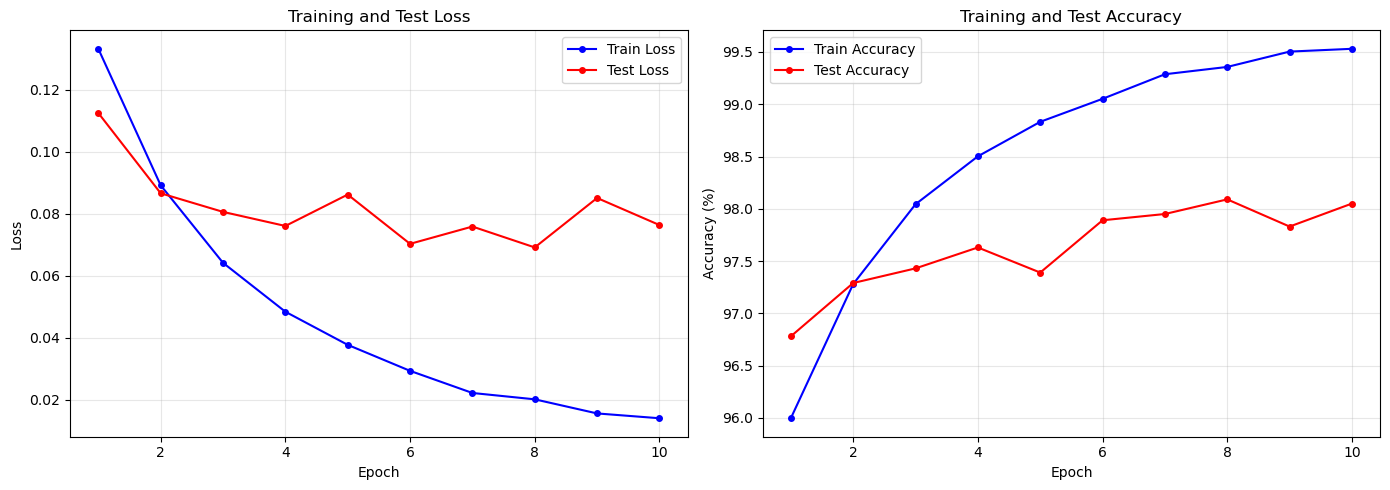

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, EPOCHS + 1)

# Loss plot
ax1.plot(epochs_range, train_losses, 'b-o', label='Train Loss', markersize=4)
ax1.plot(epochs_range, test_losses, 'r-o', label='Test Loss', markersize=4)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Test Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(epochs_range, [a * 100 for a in train_accs], 'b-o', label='Train Accuracy', markersize=4)
ax2.plot(epochs_range, [a * 100 for a in test_accs], 'r-o', label='Test Accuracy', markersize=4)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Test Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 6: Visualize Predictions

Let's see how the model performs on individual test images, including cases where it makes mistakes.

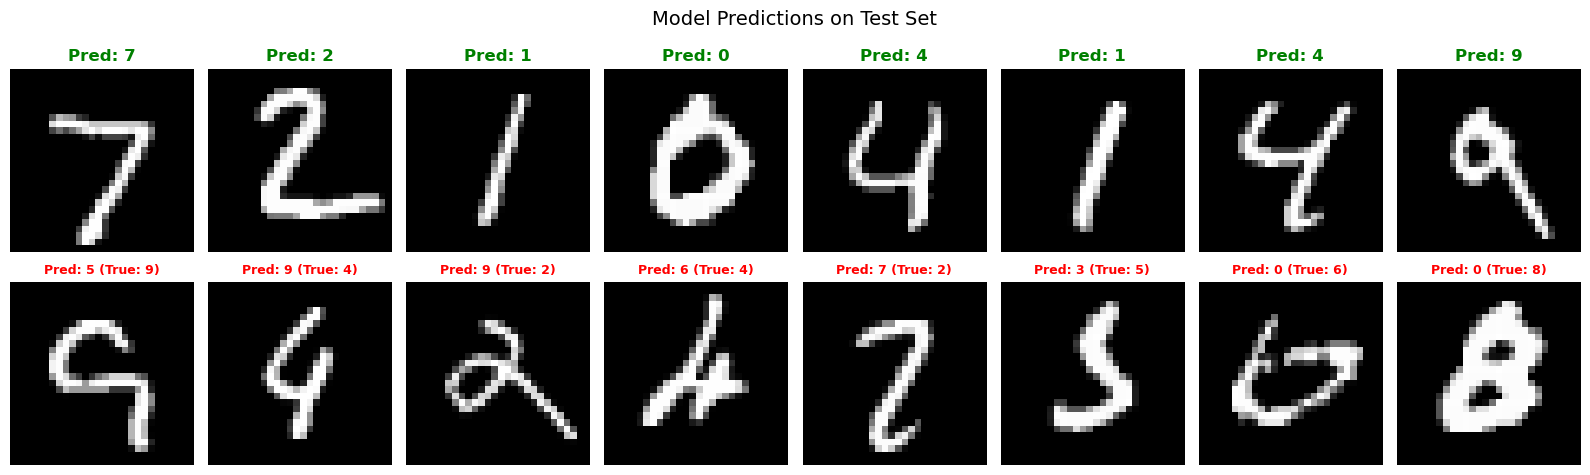


Total misclassified: 195 out of 10000 (1.95%)


In [12]:
# Get predictions on test set
model.eval()
all_preds = []
all_labels = []
all_images = []

with torch.no_grad():
    for images, labels in test_loader:
        logits = model(images.to(device))
        preds = logits.argmax(dim=1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)
        all_images.append(images)

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
all_images = torch.cat(all_images)

# Show some correct and incorrect predictions
correct_mask = all_preds == all_labels
incorrect_idx = torch.where(~correct_mask)[0]

fig, axes = plt.subplots(2, 8, figsize=(16, 5))

# Top row: correct predictions
for i in range(8):
    ax = axes[0, i]
    ax.imshow(all_images[i].squeeze(), cmap='gray')
    ax.set_title(f'Pred: {all_preds[i].item()}', color='green', fontweight='bold')
    ax.axis('off')

# Bottom row: incorrect predictions
for i in range(min(8, len(incorrect_idx))):
    ax = axes[1, i]
    idx = incorrect_idx[i].item()
    ax.imshow(all_images[idx].squeeze(), cmap='gray')
    ax.set_title(f'Pred: {all_preds[idx].item()} (True: {all_labels[idx].item()})', 
                 color='red', fontweight='bold', fontsize=9)
    ax.axis('off')

axes[0, 0].set_ylabel('Correct', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Wrong', fontsize=12, fontweight='bold')
plt.suptitle('Model Predictions on Test Set', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nTotal misclassified: {len(incorrect_idx)} out of {len(all_labels)} ({len(incorrect_idx)/len(all_labels):.2%})")

## Step 7: Confusion Matrix

A confusion matrix shows which digits the model confuses with each other. The diagonal elements represent correct classifications, and off-diagonal elements represent misclassifications.

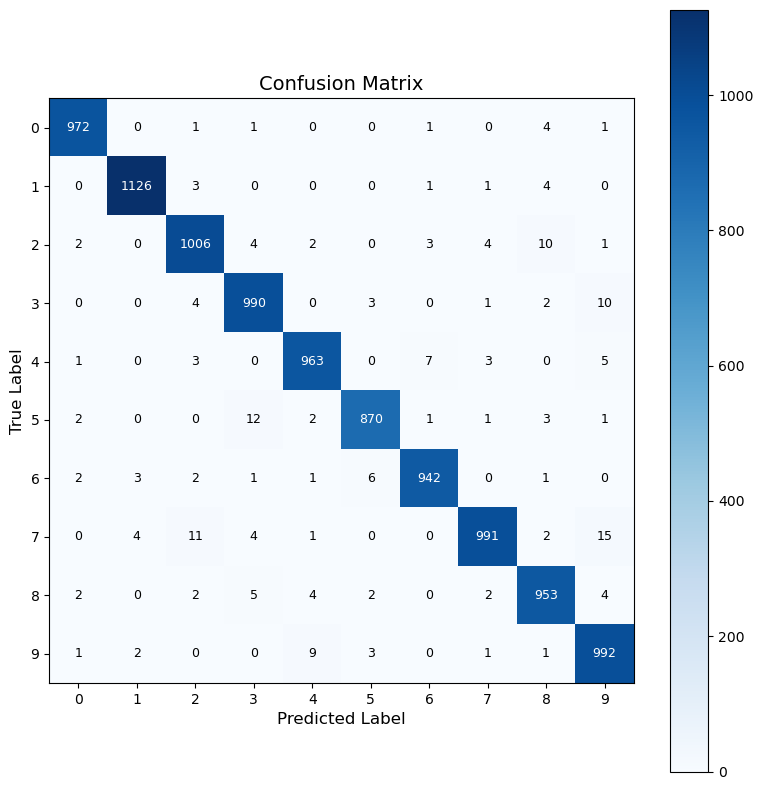


Per-class accuracy:
  Digit 0: 972/980 = 99.18%
  Digit 1: 1126/1135 = 99.21%
  Digit 2: 1006/1032 = 97.48%
  Digit 3: 990/1010 = 98.02%
  Digit 4: 963/982 = 98.07%
  Digit 5: 870/892 = 97.53%
  Digit 6: 942/958 = 98.33%
  Digit 7: 991/1028 = 96.40%
  Digit 8: 953/974 = 97.84%
  Digit 9: 992/1009 = 98.32%


In [13]:
# Compute confusion matrix
confusion = torch.zeros(10, 10, dtype=torch.int64)
for pred, true in zip(all_preds, all_labels):
    confusion[true, pred] += 1

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(confusion, cmap='Blues')

# Add text annotations
for i in range(10):
    for j in range(10):
        color = 'white' if confusion[i, j] > confusion.max() / 2 else 'black'
        ax.text(j, i, f'{confusion[i, j]}', ha='center', va='center', color=color, fontsize=9)

ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14)
ax.set_xticks(range(10))
ax.set_yticks(range(10))
plt.colorbar(im)
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\nPer-class accuracy:")
for i in range(10):
    class_total = confusion[i].sum().item()
    class_correct = confusion[i, i].item()
    print(f"  Digit {i}: {class_correct}/{class_total} = {class_correct/class_total:.2%}")

## Summary

In this tutorial, we built a fully connected neural network for MNIST digit classification.

### Key takeaways:

| Aspect | Details |
|--------|--------|
| **Dataset** | MNIST: 60k train / 10k test, 28x28 grayscale images |
| **Model** | 3-layer fully connected network (784 -> 256 -> 128 -> 10) |
| **Loss** | Cross-Entropy Loss |
| **Optimizer** | Adam (lr=0.001) |
| **Expected accuracy** | ~97-98% on test set |

### Limitations of fully connected networks for images:

- **No spatial awareness**: Flattening the image loses the 2D spatial structure
- **Too many parameters**: Every pixel connects to every neuron (784 x 256 = ~200k parameters in just the first layer)
- **Not translation invariant**: A digit shifted a few pixels would activate completely different neurons

In later tutorials, we will address these limitations using **Convolutional Neural Networks (CNNs)**.

### Exercises:

1. **Modify the architecture**: Try adding/removing layers or changing the number of neurons. How does it affect accuracy?
2. **Try different optimizers**: Replace Adam with SGD (`optim.SGD`). What learning rate works best?
3. **Add regularization**: Add `nn.Dropout(0.5)` between layers. Does it help reduce overfitting?
4. **Change the learning rate**: Try 0.01, 0.0001, and 0.00001. What happens?